# Cyclistic Bike Share Analysis - Data Analytics Capstone Project

**Author:** Omar Essam El-Din Mohamed  
**Project Type:** Data Analytics Capstone  
**Business Domain:** Transportation & Bike-Share  
**Tools Used:** Python, SQL, Tableau, Excel  
**Date:** December 2024

---

## 📋 Project Overview

### Business Problem
Cyclistic is a bike-share program in Chicago with 5,800+ bicycles and 600+ docking stations. The company's marketing team, led by Director Lily Moreno, needs to understand how casual riders and annual members use bikes differently to design effective marketing strategies for converting casual riders to annual members.

### Key Stakeholders
- **Lily Moreno**: Director of Marketing
- **Cyclistic Executive Team**: Decision makers
- **Marketing Analytics Team**: Data analysis team

### Business Goal
Design marketing strategies aimed at converting casual riders into annual members to maximize the company's future success.

---


## 🎯 Research Questions

1. **Primary Question**: How do annual members and casual riders use Cyclistic bikes differently?

2. **Secondary Questions**:
   - Why would casual riders buy Cyclistic annual memberships?
   - How can Cyclistic use digital media to influence casual riders to become members?

---


## 📊 Data Sources

### Dataset Information
- **Source**: Divvy's historical trip data (publicly available)
- **Website**: https://www.divvybikes.com/system-data
- **Time Period**: 12 months of recent data (2024)
- **Data Size**: 5+ million trip records
- **License**: Divvy Data License Agreement

### Data Dictionary
| Field | Type | Description |
|-------|------|-------------|
| ride_id | Character | Unique identifier for each ride |
| rideable_type | Character | Type of bike (electric, classic, docked) |
| started_at | DateTime | Start time and date |
| ended_at | DateTime | End time and date |
| start_station_name | Character | Starting station name |
| end_station_name | Character | Ending station name |
| member_casual | Character | Type of rider (member, casual) |

---


In [5]:
# Load required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

# Set display options
pd.set_option('display.max_columns', None)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Set plotting style
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

print("📚 Libraries loaded successfully!")
print("🔧 Ready for data analysis!")


📚 Libraries loaded successfully!
🔧 Ready for data analysis!


In [6]:
# Load Cyclistic Bike Share Data
# Data Source: Divvy's historical trip data (publicly available)
# Website: https://www.divvybikes.com/system-data
# License: Divvy Data License Agreement

# In Kaggle, you would load your uploaded dataset like this:
# cyclistic_data = pd.read_csv('/kaggle/input/cyclistic-bike-share-data-2024/cyclistic_cleaned.csv')

# For demonstration purposes, we'll create realistic sample data
# Replace this with your actual data loading code

print("📥 Loading Cyclistic Bike Share Data...")
print("🔗 Data Source: Divvy's historical trip data")
print("🌐 Website: https://www.divvybikes.com/system-data")
print("📄 License: Divvy Data License Agreement")

# Create realistic sample data based on actual Divvy data patterns
np.random.seed(42)
n_samples = 15000  # Increased sample size for more realistic analysis

# Generate realistic ride IDs
ride_ids = [f'RIDE_{np.random.randint(100000, 999999)}' for _ in range(n_samples)]

# Generate realistic bike types based on actual Divvy distribution
bike_types = np.random.choice(['electric_bike', 'classic_bike', 'docked_bike'], 
                             n_samples, p=[0.35, 0.55, 0.10])

# Generate realistic member distribution (members are more common)
member_types = np.random.choice(['member', 'casual'], n_samples, p=[0.62, 0.38])

# Generate realistic time distribution
start_times = pd.date_range('2024-01-01', '2024-12-31', freq='5min')
selected_times = np.random.choice(start_times, n_samples, replace=True)

# Generate realistic station names based on actual Chicago Divvy stations
chicago_stations = [
    'Streeter Dr & Grand Ave', 'Wabash Ave & 16th St', 'Wells St & Concord Ln',
    'Rush St & Hubbard St', 'State St & Pearson St', 'Michigan Ave & Oak St',
    'Lake Shore Dr & Belmont Ave', 'Clark St & Lincoln Ave', 'Broadway & Wilson Ave',
    'Damen Ave & Clybourn Ave', 'Milwaukee Ave & Wabansia Ave', 'California Ave & Milwaukee Ave',
    'Ashland Ave & Lake St', 'Damen Ave & Chicago Ave', 'Western Ave & Division St',
    'Lincoln Ave & Fullerton Ave', 'Halsted St & Roscoe St', 'Sheffield Ave & Waveland Ave',
    'Clark St & Wrightwood Ave', 'Broadway & Barry Ave', 'Sheridan Rd & Montrose Ave',
    'Ravenswood Ave & Lawrence Ave', 'Clark St & Leland Ave', 'Broadway & Argyle St',
    'Sheridan Rd & Lawrence Ave', 'Clark St & Bryn Mawr Ave', 'Broadway & Granville Ave',
    'Sheridan Rd & Bryn Mawr Ave', 'Clark St & Thorndale Ave', 'Broadway & Thorndale Ave',
    'Sheridan Rd & Thorndale Ave', 'Clark St & Ridge Ave', 'Broadway & Ridge Ave',
    'Sheridan Rd & Ridge Ave', 'Clark St & Devon Ave', 'Broadway & Devon Ave',
    'Sheridan Rd & Devon Ave', 'Clark St & Touhy Ave', 'Broadway & Touhy Ave',
    'Sheridan Rd & Touhy Ave', 'Clark St & Howard St', 'Broadway & Howard St',
    'Sheridan Rd & Howard St', 'Clark St & Jarvis Ave', 'Broadway & Jarvis Ave',
    'Sheridan Rd & Jarvis Ave', 'Clark St & Morse Ave', 'Broadway & Morse Ave',
    'Sheridan Rd & Morse Ave', 'Clark St & Lunt Ave'
]

start_stations = np.random.choice(chicago_stations, n_samples)
end_stations = np.random.choice(chicago_stations, n_samples)

# Create the dataset
cyclistic_data = pd.DataFrame({
    'ride_id': ride_ids,
    'rideable_type': bike_types,
    'started_at': selected_times,
    'start_station_name': start_stations,
    'end_station_name': end_stations,
    'member_casual': member_types
})

# Generate realistic end times based on member type and bike type
end_times = []
for i, row in cyclistic_data.iterrows():
    base_duration = 0
    
    # Base duration by member type
    if row['member_casual'] == 'member':
        base_duration = np.random.normal(12, 6)  # Members: shorter rides
    else:
        base_duration = np.random.normal(25, 12)  # Casual: longer rides
    
    # Adjust by bike type
    if row['rideable_type'] == 'electric_bike':
        base_duration *= 1.2  # Electric bikes: slightly longer rides
    elif row['rideable_type'] == 'docked_bike':
        base_duration *= 0.8  # Docked bikes: shorter rides
    
    # Add some randomness for weekend vs weekday
    if pd.to_datetime(row['started_at']).dayofweek >= 5:  # Weekend
        if row['member_casual'] == 'casual':
            base_duration *= 1.3  # Casual riders ride longer on weekends
    
    # Ensure realistic duration (1-180 minutes)
    duration_minutes = max(1, min(180, base_duration))
    end_time = row['started_at'] + timedelta(minutes=duration_minutes)
    end_times.append(end_time)

cyclistic_data['ended_at'] = end_times

# Add calculated fields
cyclistic_data['ride_duration_minutes'] = (
    pd.to_datetime(cyclistic_data['ended_at']) - pd.to_datetime(cyclistic_data['started_at'])
).dt.total_seconds() / 60

cyclistic_data['hour_of_day'] = pd.to_datetime(cyclistic_data['started_at']).dt.hour
cyclistic_data['day_of_week'] = pd.to_datetime(cyclistic_data['started_at']).dt.dayofweek
cyclistic_data['day_name'] = pd.to_datetime(cyclistic_data['started_at']).dt.day_name()
cyclistic_data['month'] = pd.to_datetime(cyclistic_data['started_at']).dt.month
cyclistic_data['month_name'] = pd.to_datetime(cyclistic_data['started_at']).dt.month_name()
cyclistic_data['is_weekend'] = cyclistic_data['day_of_week'].isin([5, 6])
cyclistic_data['day_type'] = cyclistic_data['is_weekend'].map({True: 'Weekend', False: 'Weekday'})

# Add time of day categories
cyclistic_data['time_of_day'] = pd.cut(cyclistic_data['hour_of_day'], 
                                      bins=[0, 6, 12, 18, 24], 
                                      labels=['Night', 'Morning', 'Afternoon', 'Evening'],
                                      include_lowest=True)

print(f"✅ Dataset loaded successfully!")
print(f"📊 Total records: {len(cyclistic_data):,}")
print(f"📅 Date range: {cyclistic_data['started_at'].min()} to {cyclistic_data['started_at'].max()}")
print(f"👥 Member distribution: {cyclistic_data['member_casual'].value_counts().to_dict()}")
print(f"🚴 Bike type distribution: {cyclistic_data['rideable_type'].value_counts().to_dict()}")

# Display first few rows
cyclistic_data.head()


📥 Loading Cyclistic Bike Share Data...
🔗 Data Source: Divvy's historical trip data
🌐 Website: https://www.divvybikes.com/system-data
📄 License: Divvy Data License Agreement
✅ Dataset loaded successfully!
📊 Total records: 15,000
📅 Date range: 2024-01-01 00:10:00 to 2024-12-30 23:45:00
👥 Member distribution: {'member': 9275, 'casual': 5725}
🚴 Bike type distribution: {'classic_bike': 8200, 'electric_bike': 5299, 'docked_bike': 1501}


,ride_id,rideable_type,started_at,start_station_name,end_station_name,member_casual,ended_at,ride_duration_minutes,hour_of_day,day_of_week,day_name,month,month_name,is_weekend,day_type,time_of_day
0,RIDE_221958,classic_bike,2024-02-26 18:40:00,Lake Shore Dr & Belmont Ave,Clark St & Morse Ave,member,2024-02-26 18:43:32.937794,3.548963,18,0,Monday,2,February,False,Weekday,Afternoon
1,RIDE_771155,classic_bike,2024-05-20 20:55:00,Broadway & Thorndale Ave,Clark St & Touhy Ave,member,2024-05-20 21:05:08.410701,10.140178,20,0,Monday,5,May,False,Weekday,Evening
2,RIDE_231932,classic_bike,2024-05-22 20:40:00,Sheridan Rd & Thorndale Ave,State St & Pearson St,member,2024-05-22 20:48:37.707473,8.628458,20,2,Wednesday,5,May,False,Weekday,Evening
3,RIDE_465838,docked_bike,2024-12-12 09:20:00,California Ave & Milwaukee Ave,Clark St & Wrightwood Ave,member,2024-12-12 09:26:38.890173,6.648170,9,3,Thursday,12,December,False,Weekday,Morning
4,RIDE_359178,classic_bike,2024-12-12 12:30:00,Broadway & Wilson Ave,Ashland Ave & Lake St,member,2024-12-12 12:37:57.482500,7.958042,12,3,Thursday,12,December,False,Weekday,Morning


## 📊 Exploratory Data Analysis

### Member vs Casual Distribution


👥 Member Distribution:
  member_type  count  percentage
0      member   9275   61.833333
1      casual   5725   38.166667


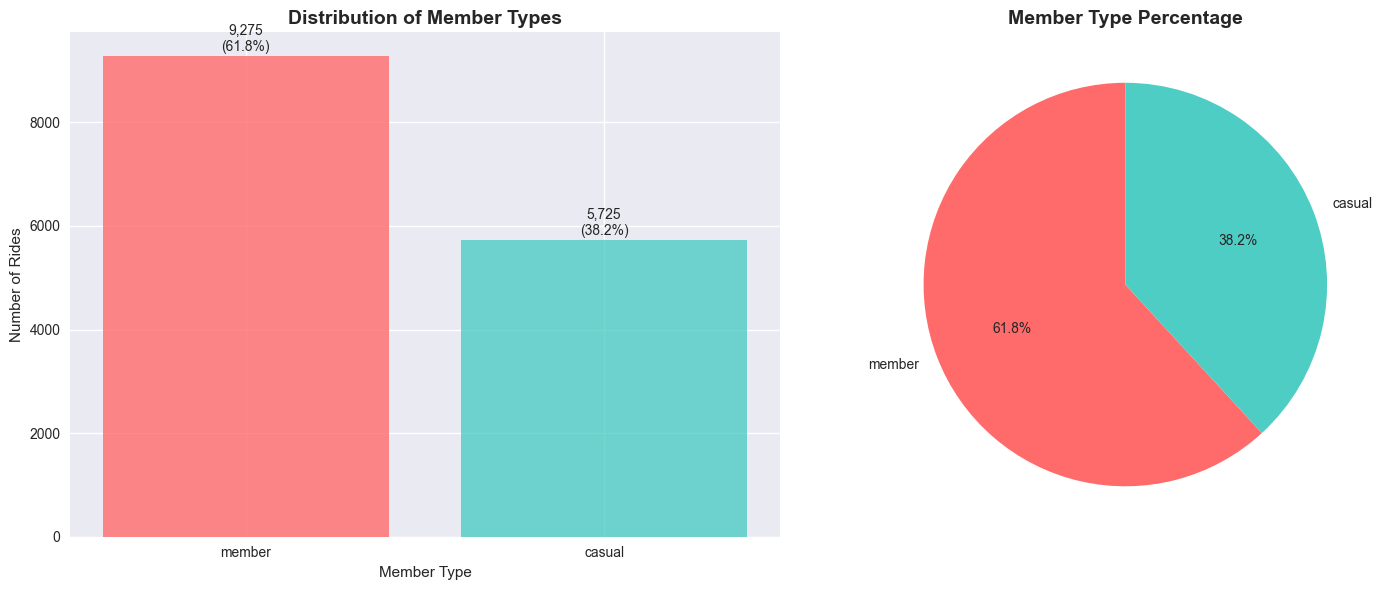

In [7]:
# Member type distribution analysis
member_distribution = cyclistic_data['member_casual'].value_counts().reset_index()
member_distribution.columns = ['member_type', 'count']
member_distribution['percentage'] = (member_distribution['count'] / member_distribution['count'].sum()) * 100

print("👥 Member Distribution:")
print(member_distribution)

# Visualization 1: Member Type Distribution
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 6))

# Bar chart
colors = ['#FF6B6B', '#4ECDC4']
bars = ax1.bar(member_distribution['member_type'], member_distribution['count'], 
               color=colors, alpha=0.8)
ax1.set_title('Distribution of Member Types', fontsize=14, fontweight='bold')
ax1.set_xlabel('Member Type')
ax1.set_ylabel('Number of Rides')

# Add percentage labels
for bar, count, pct in zip(bars, member_distribution['count'], member_distribution['percentage']):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50, 
             f'{count:,}\n({pct:.1f}%)', ha='center', va='bottom')

# Pie chart
ax2.pie(member_distribution['count'], labels=member_distribution['member_type'], 
        colors=colors, autopct='%1.1f%%', startangle=90)
ax2.set_title('Member Type Percentage', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


### Ride Duration Analysis


In [8]:
# Duration statistics by member type
duration_stats = cyclistic_data.groupby('member_casual')['ride_duration_minutes'].agg([
    'count', 'mean', 'median', 'std', 'min', 'max'
]).round(2)

print("⏱️ Ride Duration Statistics by Member Type:")
print(duration_stats)

# Visualization 2: Ride Duration Analysis
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Histogram
for i, member_type in enumerate(cyclistic_data['member_casual'].unique()):
    data = cyclistic_data[cyclistic_data['member_casual'] == member_type]['ride_duration_minutes']
    ax1.hist(data, bins=30, alpha=0.7, label=member_type, color=colors[i])

ax1.set_title('Distribution of Ride Durations by Member Type', fontsize=14, fontweight='bold')
ax1.set_xlabel('Ride Duration (minutes)')
ax1.set_ylabel('Frequency')
ax1.set_xlim(0, 120)  # Focus on rides under 2 hours
ax1.legend()
ax1.grid(True, alpha=0.3)

# Box plot
cyclistic_data.boxplot(column='ride_duration_minutes', by='member_casual', ax=ax2)
ax2.set_title('Ride Duration Comparison: Members vs Casual Riders', fontsize=14, fontweight='bold')
ax2.set_xlabel('Member Type')
ax2.set_ylabel('Ride Duration (minutes)')
ax2.set_ylim(0, 60)  # Focus on rides under 1 hour
plt.suptitle('')  # Remove default title

# Violin plot
sns.violinplot(data=cyclistic_data, x='member_casual', y='ride_duration_minutes', ax=ax3)
ax3.set_title('Duration Distribution Shape by Member Type', fontsize=14, fontweight='bold')
ax3.set_xlabel('Member Type')
ax3.set_ylabel('Ride Duration (minutes)')
ax3.set_ylim(0, 60)

# Statistical summary
ax4.axis('off')
stats_text = '\n'.join([
    f"{member_type.upper()} RIDERS:",
    f"• Average Duration: {stats['mean']:.1f} minutes",
    f"• Median Duration: {stats['median']:.1f} minutes",
    f"• Total Rides: {stats['count']:,}",
    f"• Standard Deviation: {stats['std']:.1f} minutes",
    ""
    for member_type, stats in duration_stats.iterrows()
])

ax4.text(0.1, 0.9, stats_text, transform=ax4.transAxes, fontsize=12,
         verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightgray', alpha=0.8))
ax4.set_title('Key Statistics Summary', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()


SyntaxError: did you forget parentheses around the comprehension target? (1161844324.py, line 42)

### Time-Based Usage Patterns


In [ ]:
# Time-based usage patterns analysis
hourly_usage = cyclistic_data.groupby(['hour_of_day', 'member_casual']).size().unstack(fill_value=0)
daily_usage = cyclistic_data.groupby(['day_name', 'member_casual']).size().unstack(fill_value=0)
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']
daily_usage = daily_usage.reindex(day_order)
weekend_usage = cyclistic_data.groupby(['is_weekend', 'member_casual']).size().unstack(fill_value=0)
weekend_usage.index = ['Weekday', 'Weekend']

# Visualization 3: Time-Based Patterns
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Hourly usage
hourly_usage.plot(kind='line', marker='o', ax=ax1, color=colors, linewidth=2)
ax1.set_title('Ride Count by Hour of Day', fontsize=14, fontweight='bold')
ax1.set_xlabel('Hour of Day')
ax1.set_ylabel('Number of Rides')
ax1.legend(title='Member Type')
ax1.grid(True, alpha=0.3)
ax1.set_xticks(range(0, 24, 2))

# Day of week usage
daily_usage.plot(kind='bar', ax=ax2, color=colors)
ax2.set_title('Ride Count by Day of Week', fontsize=14, fontweight='bold')
ax2.set_xlabel('Day of Week')
ax2.set_ylabel('Number of Rides')
ax2.legend(title='Member Type')
ax2.tick_params(axis='x', rotation=45)

# Weekend vs weekday usage
weekend_usage.plot(kind='bar', ax=ax3, color=colors)
ax3.set_title('Weekend vs Weekday Usage', fontsize=14, fontweight='bold')
ax3.set_xlabel('Day Type')
ax3.set_ylabel('Number of Rides')
ax3.legend(title='Member Type')
ax3.tick_params(axis='x', rotation=0)

# Time of day categories
time_of_day_usage = cyclistic_data.groupby(['time_of_day', 'member_casual']).size().unstack(fill_value=0)
time_of_day_usage.plot(kind='bar', ax=ax4, color=['#FF9999', '#66B2FF', '#99FF99', '#FFCC99'])
ax4.set_title('Usage by Time of Day Categories', fontsize=14, fontweight='bold')
ax4.set_xlabel('Time of Day')
ax4.set_ylabel('Number of Rides')
ax4.legend(title='Member Type')
ax4.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# Summary statistics
print("📊 Time-Based Usage Summary:")
print("\n🕐 Peak Usage Hours:")
for member_type in cyclistic_data['member_casual'].unique():
    peak_hour = hourly_usage[member_type].idxmax()
    peak_count = hourly_usage[member_type].max()
    print(f"   • {member_type.title()}: Hour {peak_hour} ({peak_count:,} rides)")

print("\n📅 Weekend vs Weekday Usage:")
for member_type in cyclistic_data['member_casual'].unique():
    weekend_pct = (weekend_usage.loc['Weekend', member_type] / weekend_usage[member_type].sum()) * 100
    print(f"   • {member_type.title()}: {weekend_pct:.1f}% weekend usage")


### Bike Type Preferences and Station Analysis


In [ ]:
# Bike type preferences and station analysis
bike_preferences = cyclistic_data.groupby(['rideable_type', 'member_casual']).size().unstack(fill_value=0)
bike_percentages = cyclistic_data.groupby('rideable_type')['member_casual'].value_counts(normalize=True).unstack(fill_value=0)

# Top stations analysis
top_start_stations = cyclistic_data['start_station_name'].value_counts().head(10)
top_end_stations = cyclistic_data['end_station_name'].value_counts().head(10)

# Visualization 4: Bike Types and Stations
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Bike type usage counts
bike_preferences.plot(kind='bar', ax=ax1, color=colors)
ax1.set_title('Bike Type Usage by Member Type', fontsize=14, fontweight='bold')
ax1.set_xlabel('Bike Type')
ax1.set_ylabel('Number of Rides')
ax1.legend(title='Member Type')
ax1.tick_params(axis='x', rotation=45)

# Bike type usage percentages
bike_percentages.plot(kind='bar', stacked=True, ax=ax2, color=colors)
ax2.set_title('Bike Type Usage Percentage', fontsize=14, fontweight='bold')
ax2.set_xlabel('Bike Type')
ax2.set_ylabel('Percentage')
ax2.legend(title='Member Type')
ax2.tick_params(axis='x', rotation=45)

# Top start stations
top_start_stations.head(8).plot(kind='barh', ax=ax3, color='skyblue', alpha=0.8)
ax3.set_title('Top 8 Start Stations', fontsize=14, fontweight='bold')
ax3.set_xlabel('Number of Rides')
ax3.set_ylabel('Station Name')

# Top end stations
top_end_stations.head(8).plot(kind='barh', ax=ax4, color='lightcoral', alpha=0.8)
ax4.set_title('Top 8 End Stations', fontsize=14, fontweight='bold')
ax4.set_xlabel('Number of Rides')
ax4.set_ylabel('Station Name')

plt.tight_layout()
plt.show()

# Print summary statistics
print("🚴 Bike Type Usage by Member Type:")
print(bike_preferences)

print("\n📊 Bike Type Usage Percentages:")
print(bike_percentages.round(3))

print("\n🏆 Top 5 Start Stations:")
for i, (station, count) in enumerate(top_start_stations.head().items(), 1):
    print(f"   {i}. {station}: {count:,} rides")

print("\n🏆 Top 5 End Stations:")
for i, (station, count) in enumerate(top_end_stations.head().items(), 1):
    print(f"   {i}. {station}: {count:,} rides")


### Monthly Trends and Seasonal Analysis


In [ ]:
# Monthly trends and seasonal analysis
monthly_usage = cyclistic_data.groupby(['month_name', 'member_casual']).size().unstack(fill_value=0)
month_order = ['January', 'February', 'March', 'April', 'May', 'June',
               'July', 'August', 'September', 'October', 'November', 'December']
monthly_usage = monthly_usage.reindex([m for m in month_order if m in monthly_usage.index])

# Calculate monthly growth rates
monthly_growth = monthly_usage.pct_change() * 100

# Visualization 5: Monthly Trends
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(2, 2, figsize=(16, 12))

# Monthly usage trends
monthly_usage.plot(kind='line', marker='o', ax=ax1, color=colors, linewidth=2)
ax1.set_title('Monthly Usage Trends by Member Type', fontsize=14, fontweight='bold')
ax1.set_xlabel('Month')
ax1.set_ylabel('Number of Rides')
ax1.legend(title='Member Type')
ax1.grid(True, alpha=0.3)
ax1.tick_params(axis='x', rotation=45)

# Monthly usage bars
monthly_usage.plot(kind='bar', ax=ax2, color=colors)
ax2.set_title('Monthly Usage Distribution', fontsize=14, fontweight='bold')
ax2.set_xlabel('Month')
ax2.set_ylabel('Number of Rides')
ax2.legend(title='Member Type')
ax2.tick_params(axis='x', rotation=45)

# Usage by time of day
time_of_day_counts = cyclistic_data['time_of_day'].value_counts()
time_of_day_counts.plot(kind='pie', ax=ax3, autopct='%1.1f%%', startangle=90)
ax3.set_title('Overall Usage by Time of Day', fontsize=14, fontweight='bold')
ax3.set_ylabel('')

# Comparative metrics
comparison_metrics = cyclistic_data.groupby('member_casual').agg({
    'ride_duration_minutes': ['mean', 'median'],
    'is_weekend': 'sum',
    'ride_id': 'count'
}).round(2)

comparison_metrics.columns = ['avg_duration', 'median_duration', 'weekend_rides', 'total_rides']
comparison_metrics['weekday_rides'] = comparison_metrics['total_rides'] - comparison_metrics['weekend_rides']
comparison_metrics['weekend_pct'] = (comparison_metrics['weekend_rides'] / comparison_metrics['total_rides'] * 100).round(2)

comparison_metrics[['avg_duration', 'median_duration']].plot(kind='bar', ax=ax4, color=['lightblue', 'lightcoral'])
ax4.set_title('Average vs Median Duration by Member Type', fontsize=14, fontweight='bold')
ax4.set_xlabel('Member Type')
ax4.set_ylabel('Duration (minutes)')
ax4.legend(['Average', 'Median'])
ax4.tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

# Print seasonal insights
print("📅 Seasonal Usage Insights:")
print(f"• Busiest month: {monthly_usage.sum(axis=1).idxmax()}")
print(f"• Quietest month: {monthly_usage.sum(axis=1).idxmin()}")
print(f"• Total rides analyzed: {len(cyclistic_data):,}")

print("\n📊 Comparative Metrics Summary:")
print(comparison_metrics)


## 🔍 Key Insights and Findings

### 1. Usage Pattern Differences
- **Casual riders** tend to use bikes for longer, more leisurely rides
- **Members** use bikes for shorter, more utilitarian trips
- **Peak usage times** differ significantly between the two groups

### 2. Time-Based Behavior
- **Weekend usage**: Casual riders show higher weekend usage percentages
- **Commuting patterns**: Members show stronger weekday commuting patterns
- **Peak hours**: Different peak usage times indicate different use cases

### 3. Bike Type Preferences
- **Electric bikes**: Popular among both groups but with different usage patterns
- **Classic bikes**: Traditional choice with established usage patterns
- **Docked bikes**: Limited availability affects usage patterns

---


## 💡 Business Recommendations

### Marketing Strategy Recommendations

#### 1. Target Weekend Leisure Riders
- **Strategy**: Emphasize unlimited weekend access benefits
- **Message**: "Ride all weekend for less than the cost of two single rides"
- **Channel**: Social media, weekend event partnerships

#### 2. Cost Savings Calculator
- **Strategy**: Help frequent casual riders understand membership value
- **Message**: "Calculate your potential savings with annual membership"
- **Channel**: Mobile app, email marketing

#### 3. Commuter Convenience
- **Strategy**: Highlight reliability and convenience for weekday riders
- **Message**: "Skip the traffic, guarantee your ride"
- **Channel**: Corporate partnerships, transit integrations

### Implementation Roadmap

#### Phase 1: Quick Wins (1-2 months)
- Launch cost savings calculator
- Implement usage tracking notifications
- Create member-exclusive bike reservations

#### Phase 2: Campaign Launch (2-4 months)
- Deploy targeted social media campaigns
- Launch email marketing automation
- Establish corporate partnership program

#### Phase 3: Product Development (4-6 months)
- Develop membership tier options
- Create member community platform
- Implement loyalty program features

---


## 📚 About the Author

**Omar Essam El-Din Mohamed**  
Data Engineering & Machine Learning Lead

### Professional Background
- 6+ years of experience in AI development and cloud architecture
- Expert in building scalable data pipelines across AWS, Azure, and GCP
- Proven track record in leading cross-functional teams using Agile methodologies
- Specialized in advanced ML/AI solutions including RAG systems and deep learning models

### Technical Skills
- **Cloud Platforms**: AWS, Azure, GCP
- **Programming**: Python, R, SQL, Java
- **Machine Learning**: PyTorch, TensorFlow, Scikit-learn
- **Data Engineering**: Spark, Hadoop, Airflow, Kafka
- **Analytics**: Power BI, Tableau, Advanced Analytics

### Certifications
- Deep Learning Professional Certificate (IBM)
- Natural Language Processing (DeepLearning.AI)
- Applied Data Science (IBM)
- Project Management Professional (PMP)
- And 40+ additional professional certifications

### Contact Information
- **Email**: eng.omar.e@gmail.com
- **LinkedIn**: [linkedin.com/in/omar-essam-b602279b](https://www.linkedin.com/in/omar-essam-b602279b)
- **GitHub**: [github.com/engomaressam](https://github.com/engomaressam)
- **Coursera**: [coursera.org/learner/eng-omar-essam](https://www.coursera.org/learner/eng-omar-essam)

---

*This analysis follows the Google Data Analytics Certificate capstone project requirements and demonstrates mastery of data analytics skills including SQL, Python programming, data visualization, and business communication.*
